### 
1. Importing the Libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter
from tkinter import messagebox, filedialog, simpledialog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, label_binarize, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, 
    precision_score, recall_score, f1_score, accuracy_score, 
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVR, SVC
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor

import joblib
from joblib import dump, load

from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# Setting up directories
MODEL_DIR = 'models'
os.makedirs(MODEL_DIR, exist_ok=True)

RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)


### 2. Loading the Dataset

In [2]:
def load_dataset():
    """Load the dataset from a CSV file selected via file dialog."""
    filepath = filedialog.askopenfilename(
        initialdir=".",
        title="Select CSV File",
        filetypes=(("CSV files", "*.csv"), ("All files", "*.*"))
    )
    if filepath:
        return pd.read_csv(filepath)
    else:
        print("No file selected.")
        return None

In [5]:
df = load_dataset()
df

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Action,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,allow,177,94,83,2,30,1,1
1,56258,3389,56258,3389,allow,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,allow,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,allow,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,allow,25358,6778,18580,31,16,13,18
...,...,...,...,...,...,...,...,...,...,...,...,...
65527,63691,80,13237,80,allow,314,192,122,6,15,4,2
65528,50964,80,13485,80,allow,4680740,67312,4613428,4675,77,985,3690
65529,54871,445,0,0,drop,70,70,0,1,0,1,0
65530,54870,445,0,0,drop,70,70,0,1,0,1,0


In [6]:
df['Action'].unique()

array(['allow', 'drop', 'deny', 'reset-both'], dtype=object)

### 3. Data Preprocessing

In [33]:
def preprocess_data(df, is_train=True, label_encoders=None):

    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]  # Drop unnamed cols

    if is_train:
        label_encoders = {}

        for col in df.select_dtypes(include='object').columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
    else:
        if label_encoders is None:
            raise ValueError("label_encoders must be provided for test/inference.")

        for col in df.select_dtypes(include='object').columns:
            if col in label_encoders:
                le = label_encoders[col]
                df[col] = le.transform(df[col].astype(str))
            else:
                raise ValueError(f"Missing encoder for column: {col}")

    df = df.fillna(df.mean(numeric_only=True))

    if is_train:
        X = df.drop(columns=['Action'])
        y = df['Action']
        return X, y, label_encoders
    else:
        return df

### 4. EDA

In [34]:
def perform_eda(X, y):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import os
    import pandas as pd

    os.makedirs("results", exist_ok=True)
    sns.set(style="whitegrid")

    plt.figure(figsize=(18, 10))

    # 1. Count Plot of Action (Classification)
    plt.subplot(2, 3, 1)
    sns.countplot(x=y, palette='viridis')
    plt.title("Distribution of Actions (Allow/Drop)")
    plt.xlabel("Action")
    plt.ylabel("Count")

    # 2. Boxplot: Bytes vs Action
    plt.subplot(2, 3, 2)
    sns.boxplot(x=y, y=X['Bytes'], palette='Set2')
    plt.title("Bytes Distribution by Action")
    plt.xlabel("Action")
    plt.ylabel("Bytes")

    # 3. Violin Plot: Packets vs Action
    plt.subplot(2, 3, 3)
    sns.violinplot(x=y, y=X['Packets'], palette='coolwarm')
    plt.title("Packets Distribution by Action")
    plt.xlabel("Action")
    plt.ylabel("Packets")

    # 4. Boxplot: Elapsed Time vs Action
    plt.subplot(2, 3, 4)
    sns.boxplot(x=y, y=X['Elapsed Time (sec)'], palette='Set1')
    plt.title("Elapsed Time Distribution by Action")
    plt.xlabel("Action")
    plt.ylabel("Elapsed Time (sec)")

    # 5. Scatter Plot: Bytes Sent vs Bytes Received
    plt.subplot(2, 3, 5)
    sns.scatterplot(x=X['Bytes Sent'], y=X['Bytes Received'], hue=y, alpha=0.6)
    plt.title("Bytes Sent vs Bytes Received by Action")
    plt.xlabel("Bytes Sent")
    plt.ylabel("Bytes Received")

    # 6. Correlation Heatmap including Action
    plt.subplot(2, 3, 6)
    df_corr = X.copy()
    df_corr['Action'] = y.factorize()[0]  # Encode categorical y for correlation
    sns.heatmap(df_corr.corr(), annot=True, fmt=".2f", cmap='coolwarm')
    plt.title("Correlation Heatmap including Action")

    plt.tight_layout()
    plt.savefig("results/eda_network_plots.png")
    plt.show()


### 5. Train Test Split

In [35]:
def train_test_splitdata(X, y, test_size=0.3, random_state=42):
    return train_test_split(X_resampled, y_resampled, test_size=test_size, random_state=random_state, stratify=y)

### 6. Metrics for Classification

In [36]:
precision = []
recall = []
fscore = []
accuracy = []

labels = ['allow', 'drop', 'deny', 'reset-both']

# Dataframes to store results
metrics_df = pd.DataFrame(columns=['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
class_report_df = pd.DataFrame()
class_performance_dfs = {}  # Dictionary to store dataframes for each class

if not os.path.exists('results'):
    os.makedirs('results')
    
    
def Calculate_Metrics(algorithm, predict, y_test,y_score):
    global metrics_df, class_report_df, class_performance_dfs
    
    categories = labels
    
    # Calculate overall metrics
    a = accuracy_score(y_test, predict) * 100
    p = precision_score(y_test, predict, average='macro') * 100
    r = recall_score(y_test, predict, average='macro') * 100
    f = f1_score(y_test, predict, average='macro') * 100

    # Append to global lists
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    
    # Create metrics dataframe entry
    metrics_entry = pd.DataFrame({
        'Algorithm': [algorithm],
        'Accuracy': [a],
        'Precision': [p],
        'Recall': [r],
        'F1-Score': [f]
    })
    metrics_df = pd.concat([metrics_df, metrics_entry], ignore_index=True)
    
    # Console output
    print(f"{algorithm} Accuracy  : {a:.2f}")
    print(f"{algorithm} Precision : {p:.2f}")
    print(f"{algorithm} Recall    : {r:.2f}")
    print(f"{algorithm} FScore    : {f:.2f}")
    
    # Confusion matrix
    conf_matrix = confusion_matrix(y_test, predict)
    
    # Classification report
    CR = classification_report(y_test, predict, target_names=[str(c) for c in categories], output_dict=True)
    print(f"{algorithm} Classification Report")
    print(f"{algorithm}\n{classification_report(y_test, predict, target_names=[str(c) for c in categories])}\n")
    
    # Classification report dataframe
    cr_df = pd.DataFrame(CR).transpose()
    cr_df['Algorithm'] = algorithm
    class_report_df = pd.concat([class_report_df, cr_df], ignore_index=False)
    
    # Class-specific performance dataframes
    for category in categories:
        class_entry = pd.DataFrame({
            'Algorithm': [algorithm],
            'Precision': [CR[str(category)]['precision'] * 100],
            'Recall': [CR[str(category)]['recall'] * 100],
            'F1-Score': [CR[str(category)]['f1-score'] * 100],
            'Support': [CR[str(category)]['support']]
        })
        
        if str(category) not in class_performance_dfs:
            class_performance_dfs[str(category)] = pd.DataFrame(columns=['Algorithm', 'Precision', 'Recall', 'F1-Score', 'Support'])
        
        class_performance_dfs[str(category)] = pd.concat([class_performance_dfs[str(category)], class_entry], ignore_index=True)
    
    # Plot and save confusion matrix
    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(conf_matrix, xticklabels=categories, yticklabels=categories, annot=True, cmap="viridis", fmt="g")
    ax.set_ylim([0, len(categories)])
    plt.title(f"{algorithm} Confusion Matrix")
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.savefig(f"results/{algorithm.replace(' ', '_')}_confusion_matrix.png")
    plt.show()
    
    # ROC Curve Plot (if y_score is provided)
    if y_score is not None:
        y_test_bin = label_binarize(y_test, classes=range(len(categories)))  # Ensure label binarization
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(len(categories)):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
        
        # Plot all ROC curves
        plt.figure(figsize=(10, 8))
        for i in range(len(categories)):
            plt.plot(fpr[i], tpr[i], label=f'Class {categories[i]} (AUC = {roc_auc[i]:.2f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.title(f"{algorithm} ROC Curves (One-vs-Rest)")
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"results/{algorithm.replace(' ', '_')}_roc_curve.png")
        plt.show()
        
def classification_graphs():
    global metrics_df, class_report_df, class_performance_dfs
    
    # Plot overall metrics
    melted_df = pd.melt(metrics_df, id_vars=['Algorithm'], 
                        value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
                        var_name='Parameters', value_name='Value')
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x='Parameters', y='Value', hue='Algorithm', data=melted_df)
    
    plt.title('Classifier Performance Comparison', fontsize=14, pad=10)
    plt.ylabel('Score (%)', fontsize=12)
    plt.xlabel('Metrics', fontsize=12)
    plt.xticks(rotation=0)
    plt.legend(title='Algorithms', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3)
    
    # Create results directory if it doesn't exist
    os.makedirs('results', exist_ok=True)
    
    plt.tight_layout()
    plt.savefig('results/classifier_performance.png')
    plt.show()
    
    # Plot class-specific performance
    for class_name, class_df in class_performance_dfs.items():
        melted_class_df = pd.melt(class_df, id_vars=['Algorithm'], 
                                 value_vars=['Precision', 'Recall', 'F1-Score'],
                                 var_name='Parameters', value_name='Value')
        
        plt.figure(figsize=(12, 6))
        ax = sns.barplot(x='Parameters', y='Value', hue='Algorithm', data=melted_class_df)
        
        plt.title(f'Class {class_name} Performance Comparison', fontsize=14, pad=10)
        plt.ylabel('Score (%)', fontsize=12)
        plt.xlabel('Metrics', fontsize=12)
        plt.xticks(rotation=0)
        plt.legend(title='Algorithms', bbox_to_anchor=(1.05, 1), loc='upper left')
        
        for container in ax.containers:
            ax.bar_label(container, fmt='%.1f', padding=3)
        
        plt.tight_layout()
        plt.savefig(f'results/class_{class_name}_performance.png')
        plt.show()
    
    # Create melted_df_new with Algorithm and overall metrics
    melted_df_new = metrics_df[['Algorithm', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].copy()
    melted_df_new = melted_df_new.round(3)  # Round to 3 decimal places for clarity
    
    return melted_df_new

###  Existing Algorithms

In [37]:
import os
from joblib import dump, load
from sklearn.linear_model import RidgeClassifier

def train_ridge_classifier(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'ridge_classifier.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
        print("Loaded RidgeClassifier model.")
    else:
        model = RidgeClassifier()
        model.fit(X_train, y_train)
        dump(model, model_path)
        print("Trained and saved new RidgeClassifier model.")

    y_pred = model.predict(X_test)
    y_score = None  # RidgeClassifier does not have predict_proba

    return Calculate_Metrics("Ridge Classifier", y_pred, y_test, y_score)


In [38]:
import os
from joblib import dump, load
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def train_lda_classifier(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'lda_classifier.joblib')
    if os.path.exists(model_path):
        model = load(model_path)
        print("Loaded LDA classifier model.")
    else:
        model = LinearDiscriminantAnalysis()
        model.fit(X_train, y_train)
        dump(model, model_path)
        print("Trained and saved new LDA classifier model.")

    y_pred = model.predict(X_test)
    y_score = None  # Add predict_proba if needed
    return Calculate_Metrics("Linear Discriminant Analysis", y_pred, y_test, y_score)


In [39]:
import os
from joblib import dump, load
from sklearn.tree import DecisionTreeClassifier

def train_decision_tree_classifier(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'decision_tree_classifier.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
        print("Loaded DecisionTreeClassifier model.")
    else:
        model = DecisionTreeClassifier(max_depth=5, random_state=42)
        model.fit(X_train, y_train)
        dump(model, model_path)
        print("Trained and saved new DecisionTreeClassifier model.")

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    return Calculate_Metrics("Decision Tree Classifier", y_pred, y_test, y_score)


In [40]:
X,y,label_names  = preprocess_data(df,is_train=True)

C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1364785556.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')
C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1364785556.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=y, y=X['Bytes'], palette='Set2')
C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1364785556.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=y, y=X['Packets'], palette='coolwarm')
C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1364785556.py:35: FutureWarning: 

Passing `palett

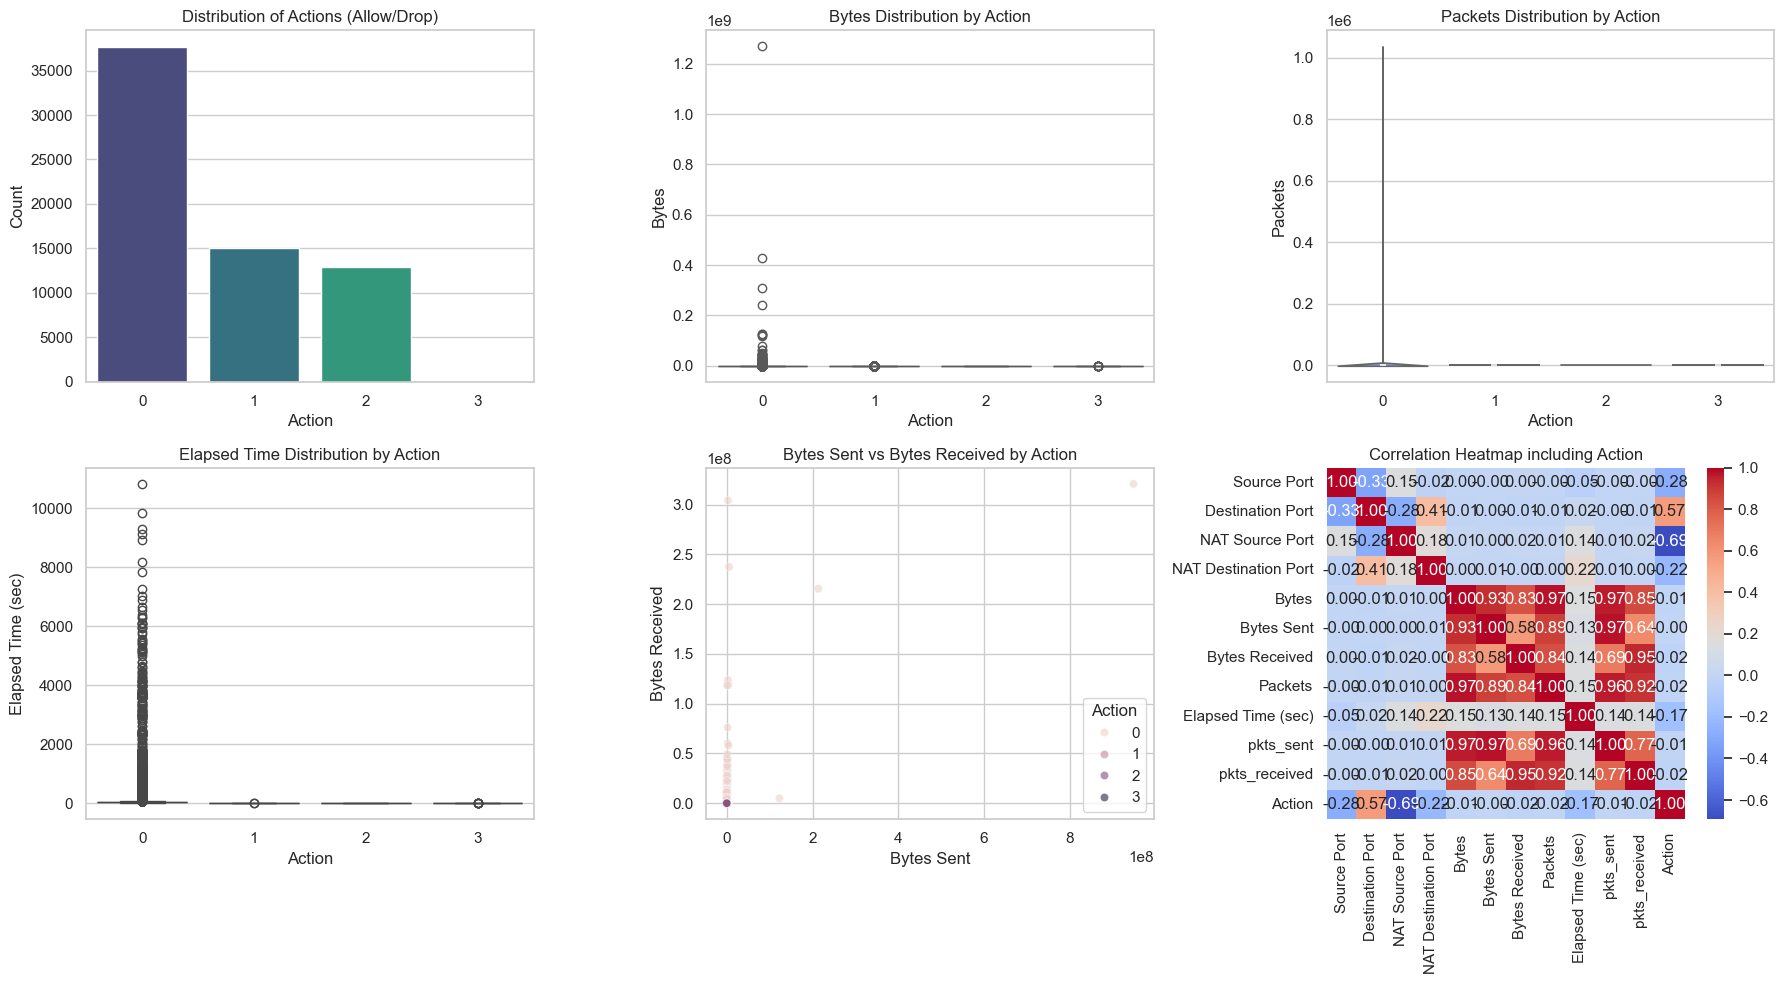

In [41]:
eda = perform_eda(X,y)

<Axes: xlabel='count', ylabel='Action'>

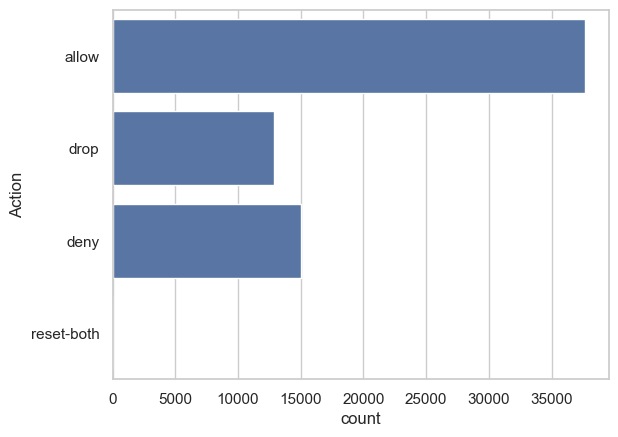

In [42]:
sns.countplot(df['Action'])

### Applying SMOTE

In [43]:
from imblearn.over_sampling import SMOTE

# Assuming you have your training features X and target y from preprocess_data

# Example after preprocessing
X, y, label_encoders = preprocess_data(df, is_train=True)

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE: {np.bincount(y)}")
print(f"After SMOTE: {np.bincount(y_resampled)}")


Before SMOTE: [37640 14987 12851    54]
After SMOTE: [37640 37640 37640 37640]


<Axes: xlabel='Action', ylabel='count'>

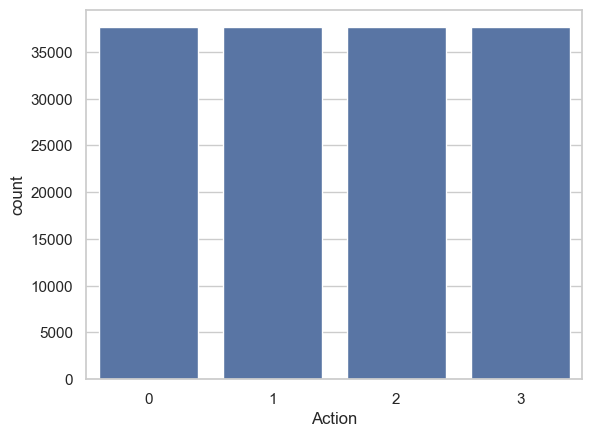

In [44]:
sns.countplot(x=y_resampled)

In [45]:
X_train, X_test, y_train, y_test = train_test_splitdata(X_resampled, y_resampled)

Loaded RidgeClassifier model.
Ridge Classifier Accuracy  : 71.42
Ridge Classifier Precision : 71.47
Ridge Classifier Recall    : 71.42
Ridge Classifier FScore    : 70.47
Ridge Classifier Classification Report


C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1640583440.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metrics_df = pd.concat([metrics_df, metrics_entry], ignore_index=True)
C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1640583440.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  class_performance_dfs[str(category)] = pd.concat([class_performance_dfs[str(category)], class_entry], ignore_index=True)
C:\Users\gannu\AppData\Local\Temp\ipykernel_13828\1640583440.py:76: FutureWarnin

Ridge Classifier
              precision    recall  f1-score   support

       allow       0.87      0.78      0.82     11292
        drop       0.65      0.56      0.60     11292
        deny       0.70      1.00      0.82     11292
  reset-both       0.64      0.52      0.58     11292

    accuracy                           0.71     45168
   macro avg       0.71      0.71      0.70     45168
weighted avg       0.71      0.71      0.70     45168




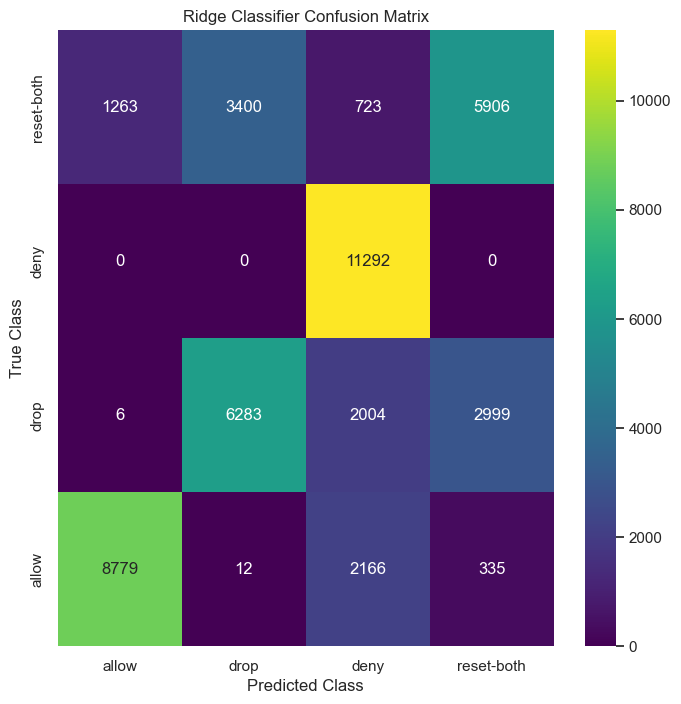

In [46]:
train_ridge_classifier(X_train, y_train, X_test, y_test)

Loaded LDA classifier model.
Linear Discriminant Analysis Accuracy  : 71.68
Linear Discriminant Analysis Precision : 71.81
Linear Discriminant Analysis Recall    : 71.68
Linear Discriminant Analysis FScore    : 70.82
Linear Discriminant Analysis Classification Report
Linear Discriminant Analysis
              precision    recall  f1-score   support

       allow       0.88      0.76      0.81     11292
        drop       0.65      0.56      0.60     11292
        deny       0.70      1.00      0.83     11292
  reset-both       0.64      0.54      0.59     11292

    accuracy                           0.72     45168
   macro avg       0.72      0.72      0.71     45168
weighted avg       0.72      0.72      0.71     45168




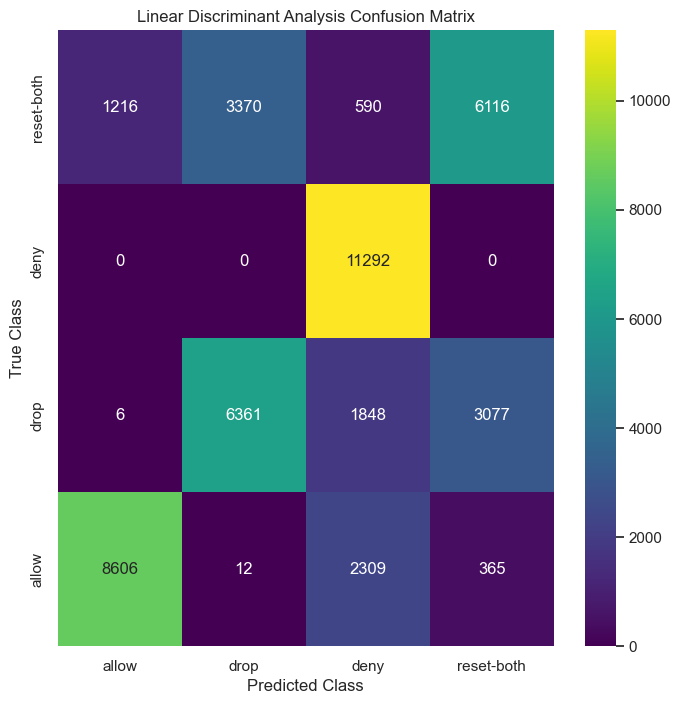

In [47]:
train_lda_classifier(X_train, y_train, X_test, y_test)

Loaded DecisionTreeClassifier model.
Decision Tree Classifier Accuracy  : 94.85
Decision Tree Classifier Precision : 95.01
Decision Tree Classifier Recall    : 94.85
Decision Tree Classifier FScore    : 94.84
Decision Tree Classifier Classification Report
Decision Tree Classifier
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     11292
        drop       0.94      0.85      0.89     11292
        deny       1.00      1.00      1.00     11292
  reset-both       0.87      0.94      0.90     11292

    accuracy                           0.95     45168
   macro avg       0.95      0.95      0.95     45168
weighted avg       0.95      0.95      0.95     45168




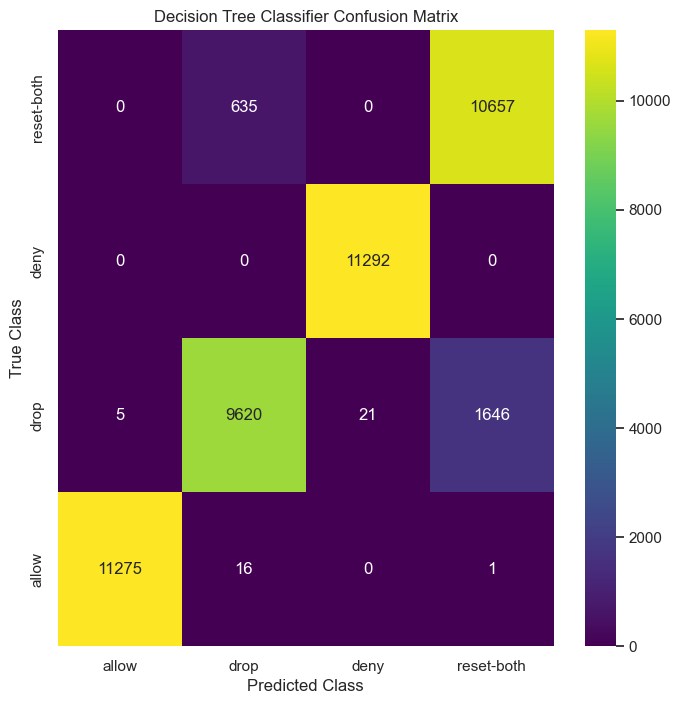

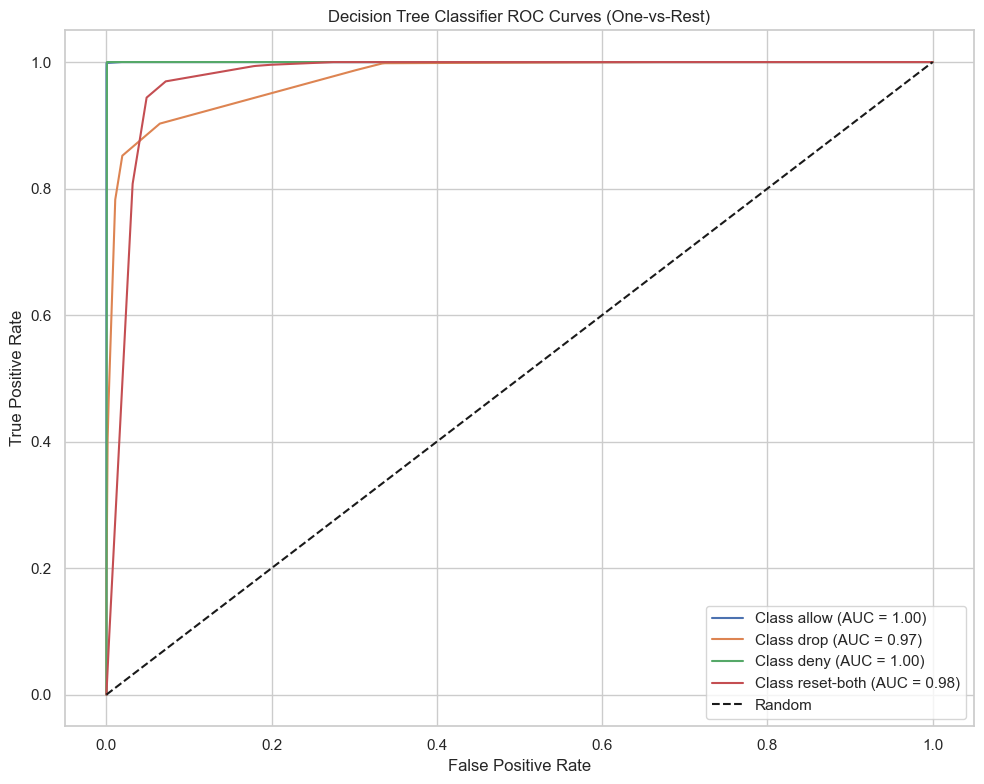

In [48]:
train_decision_tree_classifier(X_train, y_train, X_test, y_test)

### Proposed Algorithm (Hybrid)

In [49]:
import os
from joblib import dump, load
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier

def train_mlp_decision_tree_voting(X_train, y_train, X_test, y_test):
    model_path = os.path.join(MODEL_DIR, 'mlp_decision_tree_voting.joblib')

    if os.path.exists(model_path):
        model = load(model_path)
        print("Loaded MLP + Decision Tree Voting model.")
    else:
        clf1 = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
        clf2 = DecisionTreeClassifier(max_depth=100, random_state=42)

        model = VotingClassifier(
            estimators=[('mlp', clf1), ('decision_tree', clf2)],
            voting='soft'
        )
        model.fit(X_train, y_train)
        dump(model, model_path)
        print("Trained and saved new MLP + Decision Tree Voting model.")

    y_pred = model.predict(X_test)
    y_score = model.predict_proba(X_test) if hasattr(model, 'predict_proba') else None

    return Calculate_Metrics("MLP + Decision Tree Voting", y_pred, y_test, y_score)


Loaded MLP + Decision Tree Voting model.
MLP + Decision Tree Voting Accuracy  : 99.13
MLP + Decision Tree Voting Precision : 99.13
MLP + Decision Tree Voting Recall    : 99.13
MLP + Decision Tree Voting FScore    : 99.13
MLP + Decision Tree Voting Classification Report
MLP + Decision Tree Voting
              precision    recall  f1-score   support

       allow       1.00      1.00      1.00     11292
        drop       0.98      0.99      0.98     11292
        deny       1.00      1.00      1.00     11292
  reset-both       0.99      0.98      0.98     11292

    accuracy                           0.99     45168
   macro avg       0.99      0.99      0.99     45168
weighted avg       0.99      0.99      0.99     45168




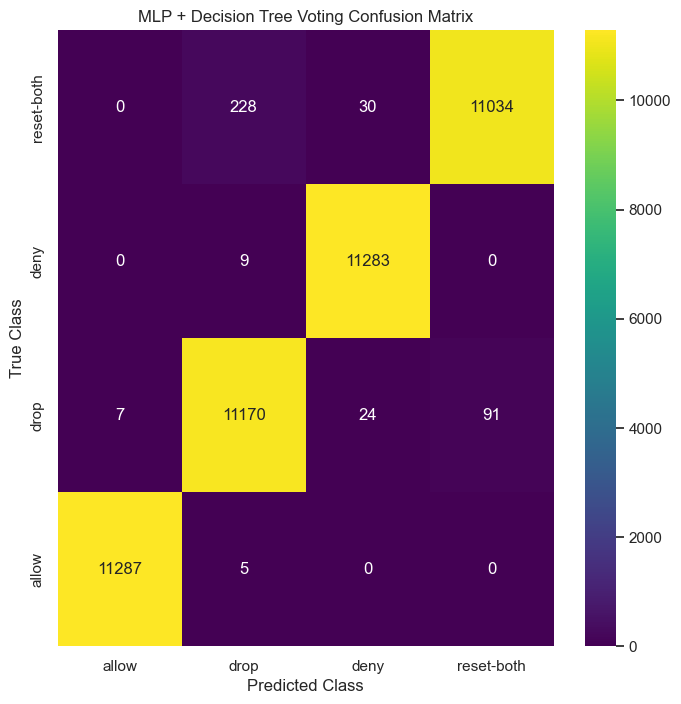

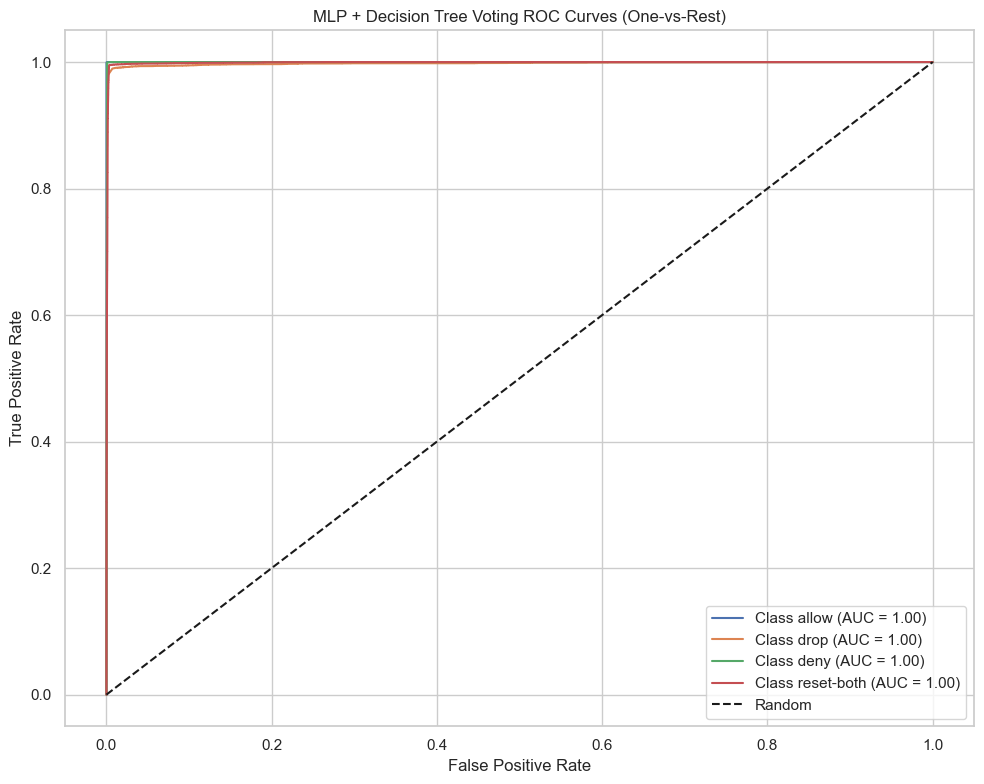

In [50]:
train_mlp_decision_tree_voting(X_train, y_train, X_test, y_test)

In [51]:
metrics_df

,Algorithm,Accuracy,Precision,Recall,F1-Score
0,Ridge Classifier,71.422246,71.465819,71.422246,70.468666
1,Linear Discriminant Analysis,71.676851,71.811428,71.676851,70.818619
2,Decision Tree Classifier,94.854764,95.011480,94.854764,94.841355
3,MLP + Decision Tree Voting,99.127701,99.130788,99.127701,99.127093


In [52]:
def classification_graphs():
    global metrics_df, class_performance_dfs, labels

    # Overall metrics bar plot
    plt.figure(figsize=(12, 8))
    metrics_melted = metrics_df.melt(id_vars='Algorithm', value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'])
    sns.barplot(data=metrics_melted, x='Algorithm', y='value', hue='variable')
    plt.title('Overall Classifier Performance Comparison')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.ylim(0, 110)
    plt.legend(title='Metric')
    plt.tight_layout()
    plt.savefig('results/overall_performance_comparison.png')
    plt.show()

    # Per-class performance plots
    for metric in ['Precision', 'Recall', 'F1-Score']:
        plt.figure(figsize=(14, 10))
        for i, label in enumerate(labels):
            plt.subplot(3, 2, i + 1)
            if label in class_performance_dfs:
                sns.barplot(x='Algorithm', y=metric, data=class_performance_dfs[label])
                plt.title(f'{label} - {metric}')
                plt.ylim(0, 110)
                plt.xticks(rotation=45)
            else:
                plt.text(0.5, 0.5, f'No data for {label}', horizontalalignment='center')
            plt.tight_layout()
        plt.savefig(f'results/per_class_{metric.lower()}_comparison.png')
        plt.show()


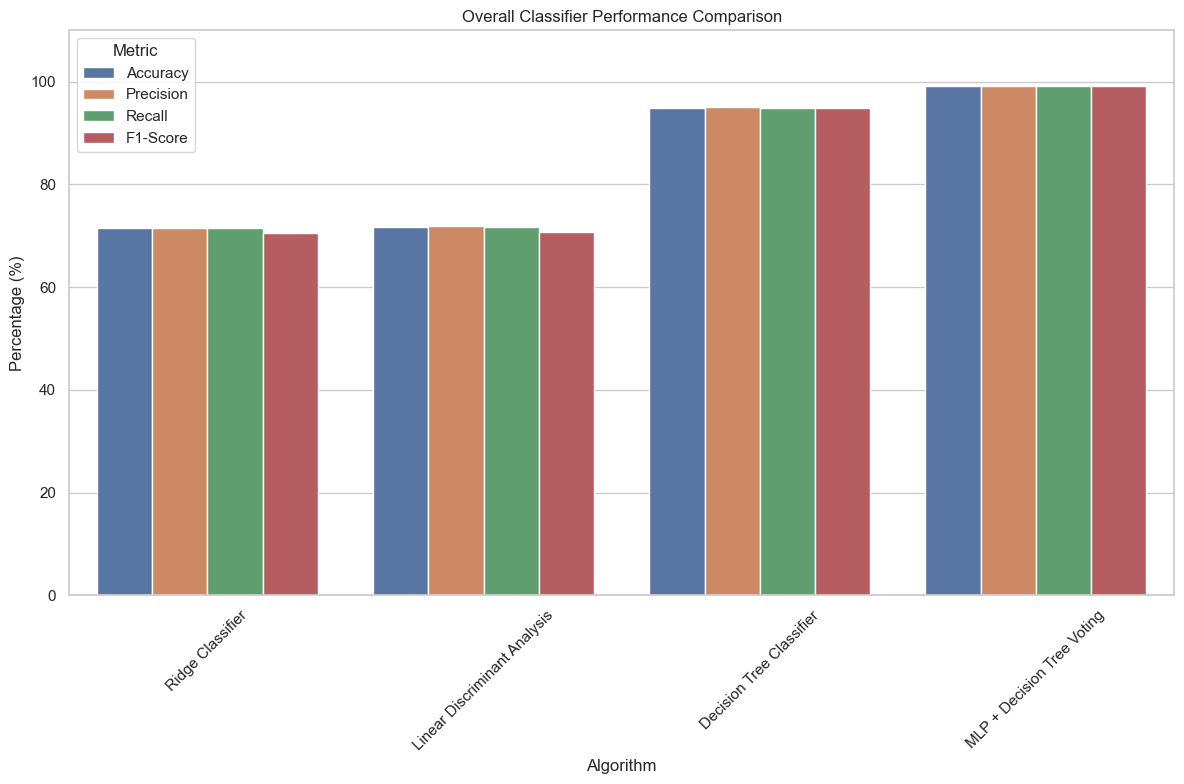

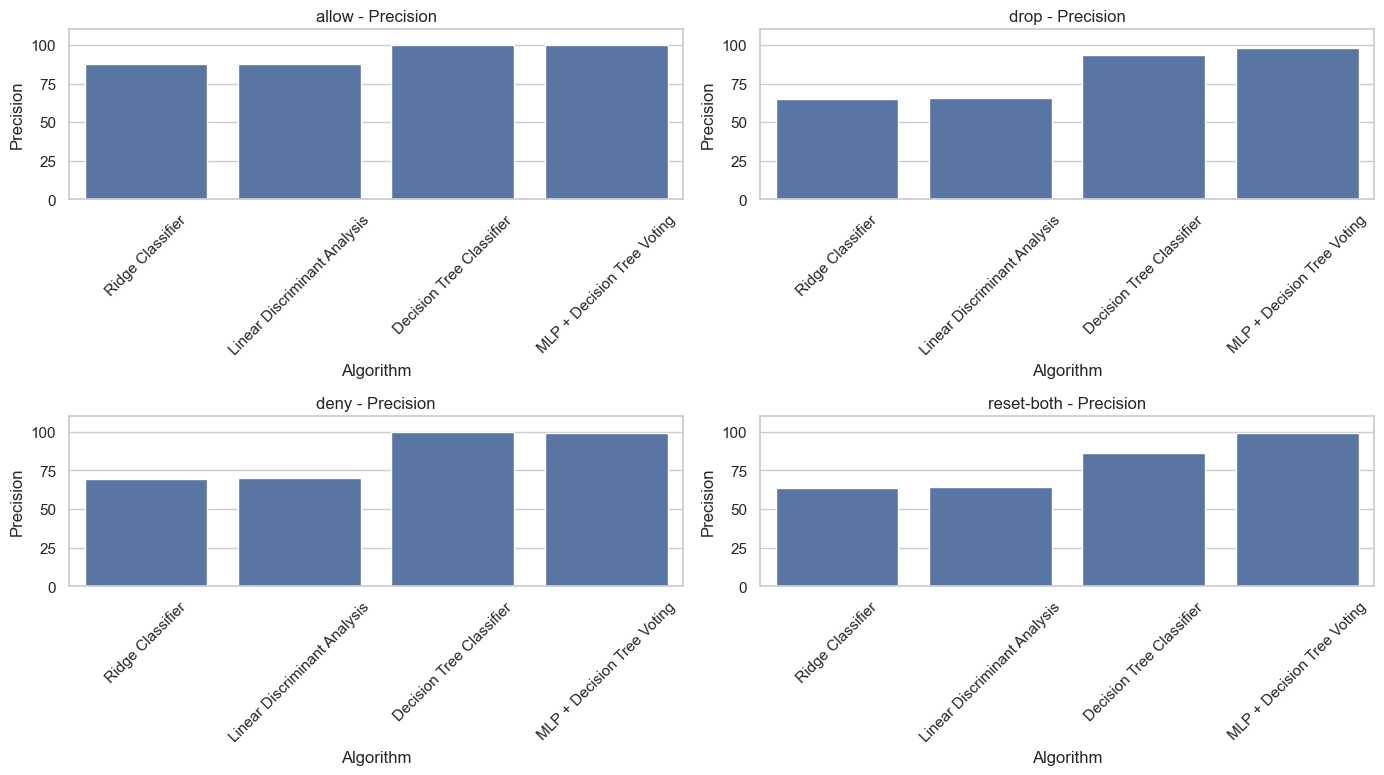

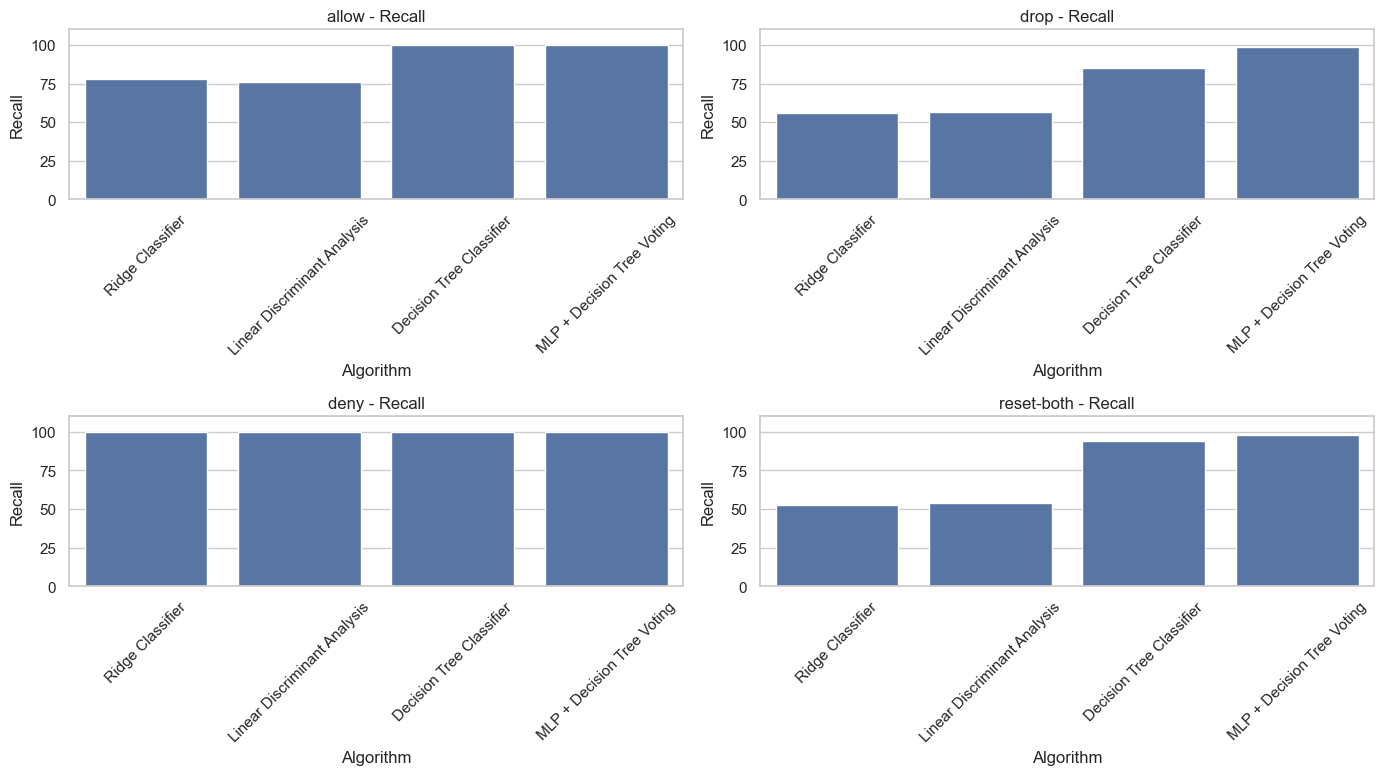

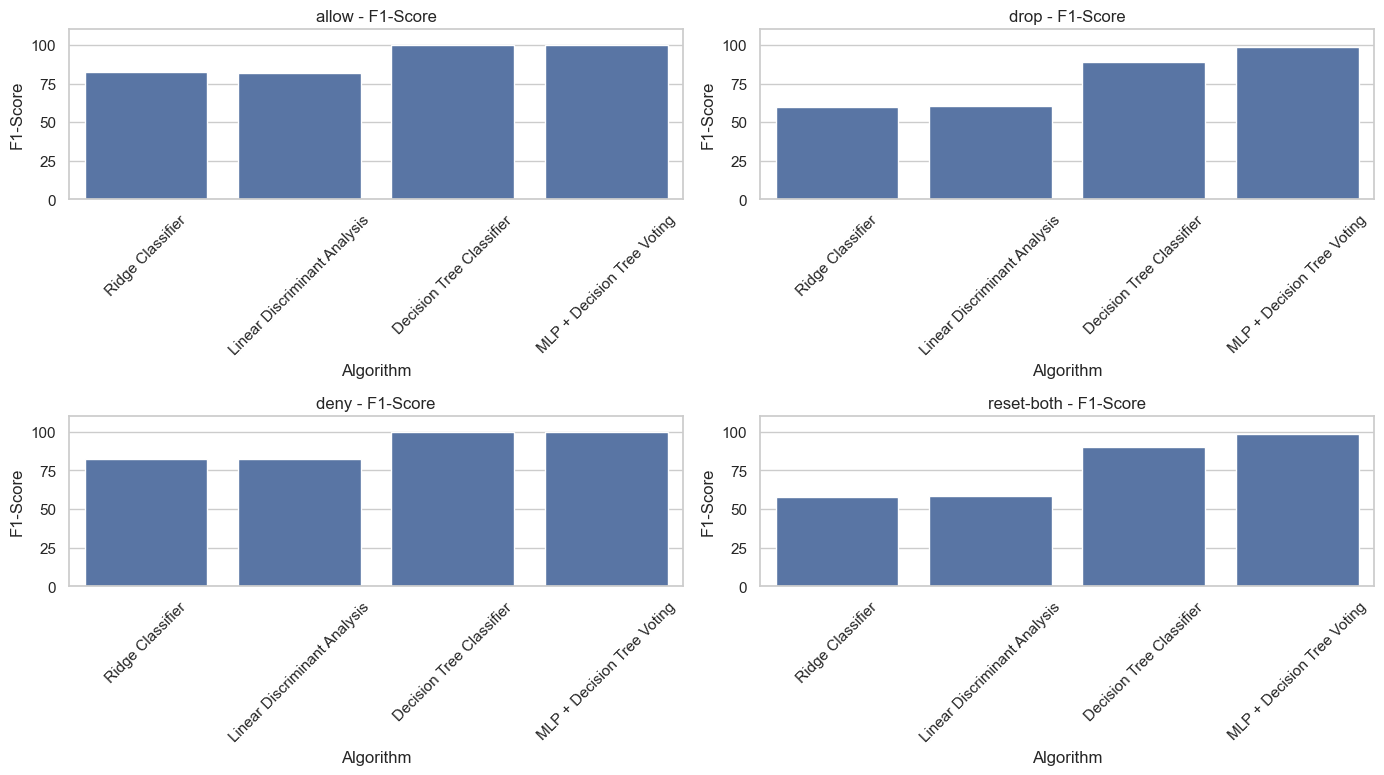

In [53]:
classification_graphs()

### 7. New Test Data

In [54]:
test_data = pd.read_csv('TestData.csv')
test_data

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,177,94,83,2,30,1,1
1,56258,3389,56258,3389,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,25358,6778,18580,31,16,13,18
5,13394,23,0,0,60,60,0,1,0,1,0
6,61078,57470,0,0,62,62,0,1,0,1,0
7,62776,62413,0,0,146,146,0,1,0,1,0
8,46448,30170,0,0,159,159,0,1,0,1,0
9,10688,25174,0,0,146,146,0,1,0,1,0


In [55]:
df1=preprocess_data(test_data, is_train=False,label_encoders=label_names)

In [56]:
df1

,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received
0,57222,53,54587,53,177,94,83,2,30,1,1
1,56258,3389,56258,3389,4768,1600,3168,19,17,10,9
2,6881,50321,43265,50321,238,118,120,2,1199,1,1
3,50553,3389,50553,3389,3327,1438,1889,15,17,8,7
4,50002,443,45848,443,25358,6778,18580,31,16,13,18
5,13394,23,0,0,60,60,0,1,0,1,0
6,61078,57470,0,0,62,62,0,1,0,1,0
7,62776,62413,0,0,146,146,0,1,0,1,0
8,46448,30170,0,0,159,159,0,1,0,1,0
9,10688,25174,0,0,146,146,0,1,0,1,0


In [57]:
def predict_and_append(df_original, df_processed, label_encoders, model_filename='mlp_decision_tree_voting.joblib'):
    model_path = os.path.join(MODEL_DIR, model_filename)

    if not os.path.exists(model_path):
        print("Model file not found.")
        return None

    model = load(model_path)

    # Predict using preprocessed test data
    y_pred = model.predict(df_processed)

    # Decode numeric labels back to original class names
    if 'Action' in label_encoders:
        y_pred_decoded = label_encoders['Action'].inverse_transform(y_pred)
    else:
        y_pred_decoded = y_pred

    # Append prediction to original DataFrame
    df_output = df_original.copy()
    df_output['Predicted Label'] = y_pred_decoded

    # Save result
    output_path = os.path.join(RESULTS_DIR, "Predictions_Appended.csv")
    df_output.to_csv(output_path, index=False)
    print(f"Predictions saved to: {output_path}")

    return df_output


### 8. Prediction on Test Data

In [58]:
final_predicted_df = predict_and_append(test_data, df1, label_names)
final_predicted_df

Predictions saved to: results\Predictions_Appended.csv


,Source Port,Destination Port,NAT Source Port,NAT Destination Port,Bytes,Bytes Sent,Bytes Received,Packets,Elapsed Time (sec),pkts_sent,pkts_received,Predicted Label
0,57222,53,54587,53,177,94,83,2,30,1,1,allow
1,56258,3389,56258,3389,4768,1600,3168,19,17,10,9,allow
2,6881,50321,43265,50321,238,118,120,2,1199,1,1,allow
3,50553,3389,50553,3389,3327,1438,1889,15,17,8,7,allow
4,50002,443,45848,443,25358,6778,18580,31,16,13,18,allow
5,13394,23,0,0,60,60,0,1,0,1,0,deny
6,61078,57470,0,0,62,62,0,1,0,1,0,deny
7,62776,62413,0,0,146,146,0,1,0,1,0,deny
8,46448,30170,0,0,159,159,0,1,0,1,0,deny
9,10688,25174,0,0,146,146,0,1,0,1,0,deny
